# MNIST Denoising Autoencoder
Welcome to a compact, hands-on project focused on image restoration. We will train a model to turn noisy handwritten digits back into clean ones. This gives a great intuition for reconstruction learning in deep learning.

In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

seed = 17
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
    backend = "CUDA"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    backend = "MPS"
else:
    device = torch.device("cpu")
    backend = "CPU"

print(f"Using device: {device} ({backend})")

Using device: cuda (CUDA)


## Data and Noise
In this part, we load the MNIST dataset and prepare it for training and testing. Then we define a small helper that adds Gaussian noise to each image. Keeping this step simple makes it easier to understand what the model is actually learning to fix.

In [2]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

def add_noise(images, noise_factor=0.5):
    noise = torch.randn_like(images) * noise_factor
    noisy_images = images + noise
    return torch.clamp(noisy_images, 0.0, 1.0)

print(f"Train samples: {len(train_dataset):,} | Test samples: {len(test_dataset):,}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]

Train samples: 60,000 | Test samples: 10,000


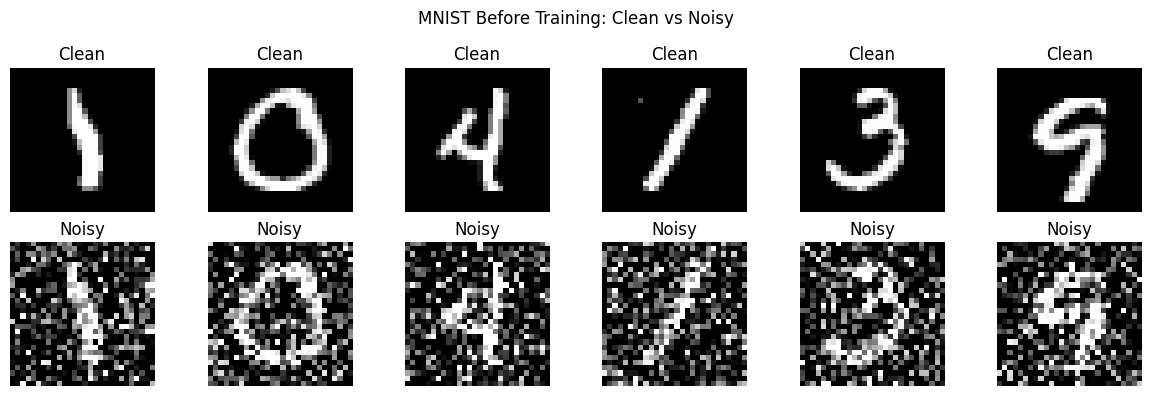

In [3]:
clean_batch, _ = next(iter(train_loader))
noisy_batch = add_noise(clean_batch)

num_examples = 6
fig, axes = plt.subplots(2, num_examples, figsize=(12, 4))
for i in range(num_examples):
    axes[0, i].imshow(clean_batch[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Clean")
    axes[0, i].axis("off")

    axes[1, i].imshow(noisy_batch[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Noisy")
    axes[1, i].axis("off")

plt.suptitle("MNIST Before Training: Clean vs Noisy")
plt.tight_layout()
plt.show()

## Autoencoder
Here we define the model with two parts: an encoder and a decoder. The encoder compresses the image into a smaller latent representation, while the decoder reconstructs it back to 28x28. This bottleneck is what encourages the network to keep only useful signal and ignore noise.

In [4]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(x.size(0), 1, 28, 28)
        return out

model = DenoisingAutoencoder(latent_dim=64).to(device)
print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## Training
Now we train the autoencoder by comparing reconstructed images against the clean originals. We use MSELoss and Adam, which are a reliable pair for this kind of pixel-level regression task. Tracking the loss per epoch helps us quickly see if learning is moving in the right direction.

Epoch 01/8 | Loss: 0.063876
Epoch 02/8 | Loss: 0.038953
Epoch 03/8 | Loss: 0.030909
Epoch 04/8 | Loss: 0.027386
Epoch 05/8 | Loss: 0.025060
Epoch 06/8 | Loss: 0.023420
Epoch 07/8 | Loss: 0.022249
Epoch 08/8 | Loss: 0.021319


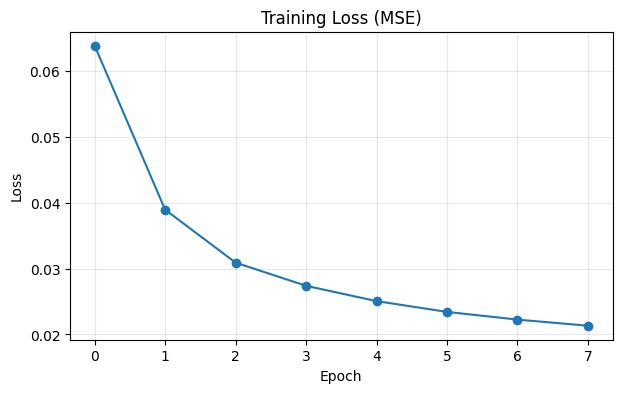

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 8
loss_history = []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for clean_imgs, _ in train_loader:
        clean_imgs = clean_imgs.to(device)
        noisy_imgs = add_noise(clean_imgs).to(device)

        optimizer.zero_grad()
        recon_imgs = model(noisy_imgs)
        loss = criterion(recon_imgs, clean_imgs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * clean_imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch:02d}/{epochs} | Loss: {epoch_loss:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(loss_history, marker="o")
plt.title("Training Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

## Final Evaluation
This final step gives a visual quality check of the model output. We plot three rows side by side: clean originals, noisy inputs, and reconstructions from the network. If training worked well, reconstructed digits should look much closer to the clean images than to the noisy ones.

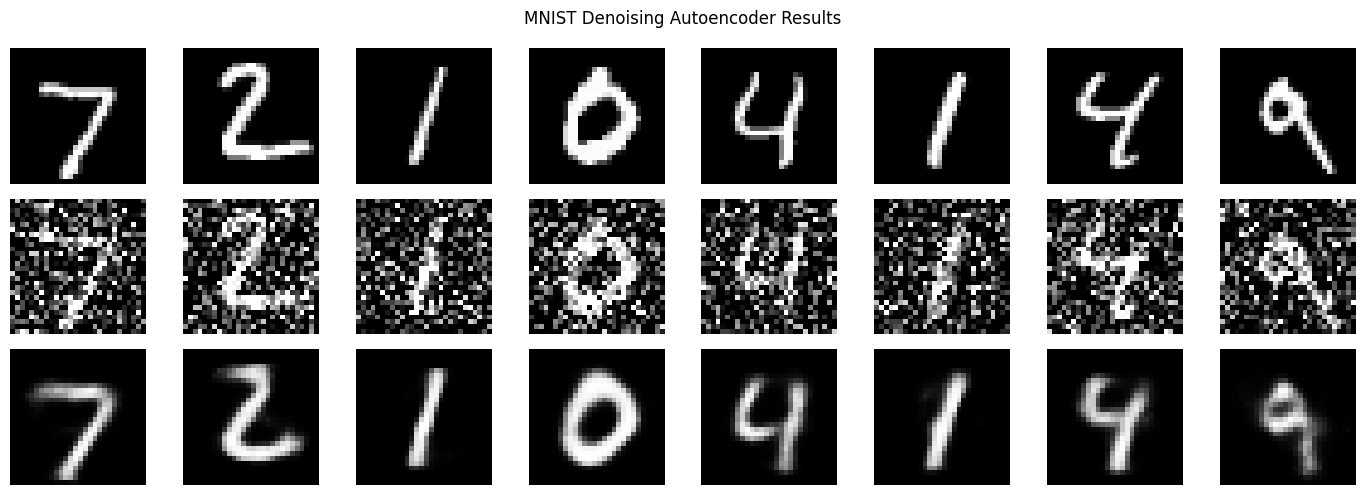

In [6]:
model.eval()
clean_imgs, _ = next(iter(test_loader))
clean_imgs = clean_imgs.to(device)
noisy_imgs = add_noise(clean_imgs).to(device)

with torch.no_grad():
    recon_imgs = model(noisy_imgs)

clean_imgs = clean_imgs.cpu()
noisy_imgs = noisy_imgs.cpu()
recon_imgs = recon_imgs.cpu()

num_examples = 8
fig, axes = plt.subplots(3, num_examples, figsize=(14, 5))
row_titles = ["Original", "Noisy", "Reconstructed"]

for i in range(num_examples):
    axes[0, i].imshow(clean_imgs[i].squeeze(), cmap="gray")
    axes[1, i].imshow(noisy_imgs[i].squeeze(), cmap="gray")
    axes[2, i].imshow(recon_imgs[i].squeeze(), cmap="gray")

    for r in range(3):
        axes[r, i].axis("off")

for r, title in enumerate(row_titles):
    axes[r, 0].set_ylabel(title, fontsize=11)

plt.suptitle("MNIST Denoising Autoencoder Results")
plt.tight_layout()
plt.show()